In [11]:
import numpy as np
import os
import astropy.units as u
import pandas as pd
from datetime import datetime, timedelta
from astropy.time import Time
import re
from sunpy.coordinates import sun
import helio_coords as hcoords

import matplotlib.animation as animation
import matplotlib as mpl
mpl.rcParams['animation.ffmpeg_path'] = '/opt/miniconda3/envs/huxt/bin/ffmpeg'

import joblib
import onnxruntime as ort

import huxt as H
import huxt_inputs as Hin
import huxt_analysis as HA

In [12]:
# Function to convert a date string to a datetime object
def convert_to_datetime(date_str):
    # List of possible date formats
    date_formats = [
        '%Y-%m-%d %H:%M:%S',
        '%Y/%m/%d %H%M',
        '%Y/%m/%d %H%M(%S)',
        '%Y/%m/%d %H%M(S)',
        '%Y/%m/%d %H:%M',
        '%Y/%m/%d %H:%M:%S',
        '%Y/%m/%d %H:%M(S)',
        '%d/%m/%Y %H:%M'
    ]
    for date_format in date_formats:
        try:
            return datetime.strptime(date_str, date_format)
        except ValueError:
            continue
    # If no format matches, return None
    return None
    
# Function to convert Time_Error from string to timedelta
def convert_to_timedelta(time_str):
    try:
        return pd.to_timedelta(time_str)
    except ValueError:
        return None

# Function to get earth's latitude
def get_earth_lat(dt):
    """
    A function to return Earth latitude for a given date, in radians
 
    Parameters
    ----------
    dt : datetime
 
    Returns
    -------
    E_lat: Earth latitude, with astropy units of radians
 
    """
    cr, cr_lon_init = Hin.datetime2huxtinputs(dt)
    
    # Use the HUXt ephemeris data to get Earth lat over the CR
    # ========================================================
    dummymodel = H.HUXt(v_boundary=np.ones(128)*400*(u.km/u.s), simtime=0.1*u.day,
                         cr_num=cr,cr_lon_init=cr_lon_init, lon_out=0.0*u.deg)
    # retrieve a bodies position at each model timestep:
    earth = dummymodel.get_observer('earth')
    # get average Earth lat
    E_lat = np.nanmean(earth.lat_c)
    E_lat = E_lat.to(u.deg)  # Convert to degrees
    return E_lat

def earth_R(mjd):
    #returns the heliocentric distance of Earth (in km). Based on Franz+Harper2002
    AU = 149597870.691
    
    #first up, switch to JD.
    JD=mjd+2400000.5
    d0=JD-2451545
    T0=d0/36525


    L2=100.4664568 + 35999.3728565*T0
    g2=L2-(102.9373481+0.3225654*T0)
    g2=g2*np.pi/180 #mean anomaly

    rAU=1.00014 - 0.01671*np.cos(g2)-0.00014*np.cos(2*g2);
    R=rAU*AU
    
    return R

In [13]:
# Read in Met Office Cone CME files
project_dirs = H._setup_dirs_()
crpath = os.path.join(project_dirs['input'],'(I)CMEs.csv')

# Load the CSV file into a DataFrame
crlist = pd.read_csv(crpath, nrows=1)

# Convert date columns to datetime objects using datetime library
date_columns = ['Time_21.5', 'Disturbance_Time']
for column in date_columns:
    crlist[column] = crlist[column].apply(lambda x: convert_to_datetime(x) if isinstance(x, str) else None)

# compute 21.5-215 transit time
crlist['tt_21'] = np.nan 
for irow in range(0, len(crlist)):
    crlist.loc[irow,'tt_21'] = crlist.loc[irow,'Disturbance_Time'] - crlist.loc[irow,'Time_21.5']
# Convert  from timedelta to days
crlist['tt_21'] = crlist['tt_21'].apply(lambda x: x.days + x.seconds / 86400 if isinstance(x, timedelta) else None)

# Add a new column with carrington rotation number of CME time
crlist['cr_num'] = crlist['Time_21.5'].apply(lambda dt: Hin.datetime2huxtinputs(dt)[0])
crlist['cr_lon_init'] = crlist['Time_21.5'].apply(lambda dt: Hin.datetime2huxtinputs(dt)[1])
crlist['earth_lat'] = crlist['Time_21.5'].apply(lambda dt: get_earth_lat(dt))

/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_11440/459609119.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2 days 05:50:00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  crlist.loc[irow,'tt_21'] = crlist.loc[irow,'Disturbance_Time'] - crlist.loc[irow,'Time_21.5']


In [14]:
# --- Load ICME  ---------------------------------------------------------------

icmelist_path = os.path.join(project_dirs['input'],
                                'Richardson_Cane_Processed_ICME_list.csv')

#HUXt run parameters
dt_scale = 4
rmin = 21.5*u.solRad
rmax = 230*u.solRad #outer boundary for HUXt runs

recon_noicmes = True #whether to remove ICMEs
icme_list = 'CaneRichardson'#'DONKI'
pre_icme_buffer = 0.2 #days
post_icme_buffer = 1 #days
sw_buffer = 2*u.day #window over which to average to fill in the solar wind during ICMEs

#fill values for ICME removal if interpolation isn't possible
vsw_fill = 450 *u.km/u.s
bx_fill = 0

In [15]:
def ICMElist(filepath):
    # -*- coding: utf-8 -*-
    """
    A script to read and process Ian Richardson's ICME list.

    Some pre-processing is required:
        Download the following webpage as a html file: 
            http://www.srl.caltech.edu/ACE/ASC/DATA/level3/icmetable2.htm
        Open in Excel, remove the year rows, delete last column (S) which is empty
        Cut out the data table only (delete header and footer)
        Save as a CSV.

    """
    
    icmes=pd.read_csv(filepath,header=None)
    #delete the first row
    icmes.drop(icmes.index[0], inplace=True)
    icmes.index = range(len(icmes))
    
    for rownum in range(0,len(icmes)):
        for colnum in range(0,3):
            #convert the three date stamps
            datestr=icmes[colnum][rownum]
            year=int(datestr[:4])
            month=int(datestr[5:7])
            day=int(datestr[8:10])
            hour=int(datestr[11:13])
            minute=int(datestr[13:15])
            #icmes.set_value(rownum,colnum,datetime(year,month, day,hour,minute,0))
            icmes.at[rownum,colnum] = datetime(year,month, day,hour,minute,0)
            
            #print(datestr)
            
        #tidy up the plasma properties
        for paramno in range(10,17):
            dv=str(icmes[paramno][rownum])
            
            #print(str(paramno)+ ' ' + dv)
            
            if dv == '...' or dv == 'dg' or dv == 'nan' or dv == '... P' or dv == '... Q':
                #icmes.set_value(rownum,paramno,np.nan)
                icmes.at[rownum,paramno] = np.nan
            else:
                #remove any remaining non-numeric characters
                dv=re.sub('[^0-9]','', dv)
                #icmes.set_value(rownum,paramno,float(dv))
                icmes.at[rownum,paramno] = float(dv)
        
    
    #chage teh column headings
    icmes=icmes.rename(columns = {0:'Shock_time',
                                  1:'ICME_start',
                                  2:'ICME_end',
                                  10:'dV',
                                  11: 'V_mean',
                                  12:'V_max',
                                  13:'Bmag',
                                  14:'MCflag',
                                  15:'Dst',
                                  16:'V_transit'})
    return icmes
  


In [16]:
# --- Remove ICME and backmap OMNI solution to 21.5 solRad ----------------------
def correct_inner_vlon_cnn_onnx(v_inner_array,
                                data_dir=os.path.join(project_dirs['input'])):
    """
    Corrects solar wind speed as a function of longitude using a 1D CNN model
    trained to account for stream interactions during backmapping from 1 AU 
    to 0.1 AU. Uses ONNX, rather than pytorch.

    Parameters:
    - v_inner_array: np.ndarray of shape (128, N) [speed vs. longitude & samples]
    - data_dir: directory containing saved scalers and ONNX model

    Returns:
    - Y_pred: np.ndarray of shape (128, N), CNN-corrected speed
    """

    # Load scalers
    y_scaler = joblib.load(os.path.join(data_dir, 'y_scaler_torch.save'))
    x_scaler = joblib.load(os.path.join(data_dir, 'x_scaler_torch.save'))

    # Transpose input to shape (N, 128) so each row is a sample
    vcarr_scaled = x_scaler.transform(v_inner_array.T)  # (N, 128)

    # Reshape to ONNX expected input: (batch_size, channels=1, length=128)
    X_input = vcarr_scaled[:, np.newaxis, :].astype(np.float32)  # (N, 1, 128)

    # Load ONNX model
    onnx_path = os.path.join(data_dir, 'CNN_model.onnx')
    ort_session = ort.InferenceSession(onnx_path)

    # Run inference
    input_name = ort_session.get_inputs()[0].name
    output = ort_session.run(None, {input_name: X_input})
    Y_pred_scaled = output[0]  # (N, 1, 128)

    # Postprocess: squeeze to (N, 128)
    Y_pred_scaled = Y_pred_scaled.squeeze(1)

    # Inverse transform
    Y_pred = y_scaler.inverse_transform(Y_pred_scaled)  # (N, 128)

    # Transpose back to (128, N) to match input shape
    return Y_pred.T

In [17]:
def preprocess_omni(cme):
    '''Download OMNI data and produce boundary conditions for a given CME'''
    
    # Download and process OMNI
    icme_time = cme['Time_21.5']
    print(icme_time)
    
    # Compute the run start and end times so that the ICME is at the end of the window

    simtime = 27.27 * u.day
    dl_starttime = icme_time - timedelta(days=28)
    dl_endtime = icme_time
    omni = Hin.get_omni(dl_starttime, dl_endtime)
        
    # Remove ICME from OMNI
    if recon_noicmes:
    
        #create a copy of the OMNI data for ICME removal, before any end padding
        omni_noicmes = omni.copy()
        #load the DONKI ICME list
        if icme_list == 'DONKI':
            icmes = Hin.get_DONKI_ICMEs(dl_starttime, dl_endtime)
        elif icme_list == 'CaneRichardson':
            icmes = ICMElist(icmelist_path)
    
        #remove all ICMEs
        params = ['V', 'BX_GSE']
        # first remove all ICMEs and add NaNs to the required parameters
        icmes['shock_mjd'] = Time(icmes['Shock_time'].to_numpy()).mjd
        icmes['end_mjd'] = Time(icmes['ICME_end'].to_numpy()).mjd
    
        for i in range(0, len(icmes)):

            icme_start = icmes['shock_mjd'][i] - pre_icme_buffer
            icme_stop = icmes['end_mjd'][i] + post_icme_buffer 
            
            mask_icme = ((omni_noicmes['mjd'] >= icme_start) &
                         (omni_noicmes['mjd'] <= icme_stop))
            
            if any(mask_icme):
                print('removing ICME #' + str(i))
                for param in params:
                    omni_noicmes.loc[mask_icme, param] = np.nan


        #now interp through all datagaps
        omni_noicmes = omni_noicmes.set_index('datetime')
        omni_noicmes[['V', 'BX_GSE']] = omni_noicmes[['V', 'BX_GSE']].interpolate(method='time').ffill().bfill()
        omni_noicmes = omni_noicmes.reset_index()
        
    #add the carrington longitude to the omni data
    def remainder(cr_frac):
        if np.isscalar(cr_frac):
            return int(np.floor(cr_frac))
        else:
            return np.floor(cr_frac).astype(int)
    cr_frac = sun.carrington_rotation_number(omni_noicmes['datetime'])
    cr = remainder(cr_frac)
    omni_noicmes['lon_carr'] = 2 * np.pi * (1 - (cr_frac - cr))    
    
    #create vCarr  with the omni time series at 1 AU
    #======================================================
    
    #unwrap the carr long
    unwrapped = np.unwrap(omni_noicmes['lon_carr'], discont=np.pi)
    #find the current value
    idx = np.argmin(np.abs(omni_noicmes['datetime'] - icme_time))
    curr_lon = unwrapped[idx]
    #find the data up to 2 pi previously 
    mask = ((unwrapped < curr_lon + 2*np.pi) & (unwrapped >= curr_lon))
    omni_chunk = omni_noicmes.loc[mask].reset_index(drop=True)
    
    #sort by carrington lon
    omni_lon = omni_chunk.sort_values(by='lon_carr').reset_index(drop=True)
    
    #now map back to the inner boundary
    Earth_R_km = hcoords.earth_R(Time(icme_time).mjd) *u.km
    vcarr_rmin_back = Hin.map_v_boundary_inwards(omni_lon['V'].to_numpy()*u.km/u.s,
                                    Earth_R_km.to(u.solRad), rmin)
    
    #interp to typical HUXt resolution
    dphi = 2*np.pi/H.huxt_constants()['nlong']
    longs = np.arange(dphi/2, 2*np.pi, dphi)
    vlon = np.interp(longs, omni_lon['lon_carr'], vcarr_rmin_back)
    
    # apply the CNN to the backmapped data
    vcarr_rmin_back_cnn = correct_inner_vlon_cnn_onnx(vlon.reshape(-1, 1))
                                    
    return simtime, vcarr_rmin_back_cnn, icme_time

2023-02-11 11:12:00


Files Downloaded: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  7.27file/s]


removing ICME #549
removing ICME #550
removing ICME #551
Rendering 200 frames. Expected time: 40 secs
mp4 file written to /Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/CR2267.mp4


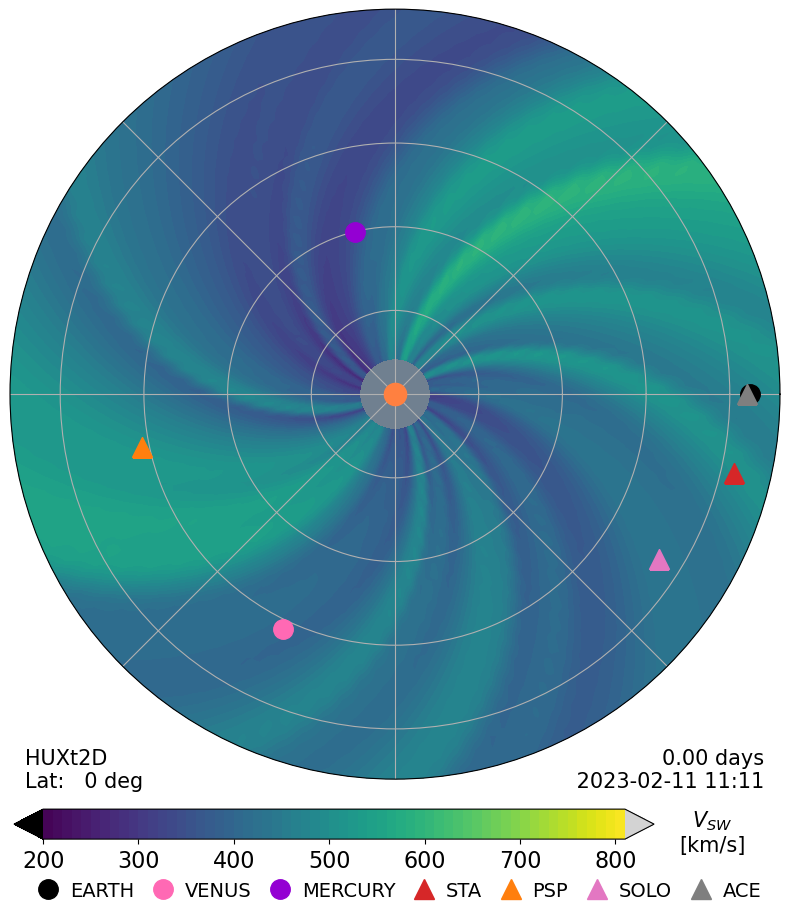

In [26]:
# <codecell> Run model
#========================================================
# Obtain OMNI boundary conditions at 21.5 rS
onecme = crlist.iloc[0,:]
simtime, vcarr_rmin_back_cnn, run_start = preprocess_omni(onecme)
    
cr, cr_lon_init = Hin.datetime2huxtinputs(run_start)
    
#========================================================
# Set up the model at 21.5 rS with backmapped OMNI
    
model = H.HUXt(v_boundary = vcarr_rmin_back_cnn.flatten() * u.km/u.s,
                         cr_num = cr, cr_lon_init = cr_lon_init,
                         simtime = simtime, r_min=rmin, r_max=rmax,
                         dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                         track_cmes = True)
    
#========================================================
# Spheroidal cone cme
'''Solve HUXt using a fixed pulse duration cone CME'''
    
cme = H.ConeCME(t_launch=0.0 * u.day,
                longitude=onecme['lon'] * u.deg,
                latitude=onecme['lat'] * u.deg,
                initial_height=rmin,
                width=2.0 * onecme['Ang_rad'] * u.deg,
                v=onecme['CME_V'] * (u.km / u.s),
                thickness=0.0 * u.solRad,
                cme_expansion=False,
                cme_fixed_duration=True,
                fixed_duration=11.0 * 60 * 60 * u.s)

model.solve([cme])
cme_out = model.cmes[0]

HA.animate(model, tag='', outputfilepath="/Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/CR2267.mp4")